# Trabajo Práctico 1 — Aprendizaje Profundo
### Carrera de Especialización en Inteligencia Artificial (CEIA)
### Facultad de Ingeniería — Universidad de Buenos Aires (FIUBA)

---

**Alumnos:**
- María Gabriela Di Grazia  — A2517
- Byron Isaac García Miranda — A2524

**Cohorte:** 25Co2026

---

In [1]:
#Agregar librerias necesarias.

import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


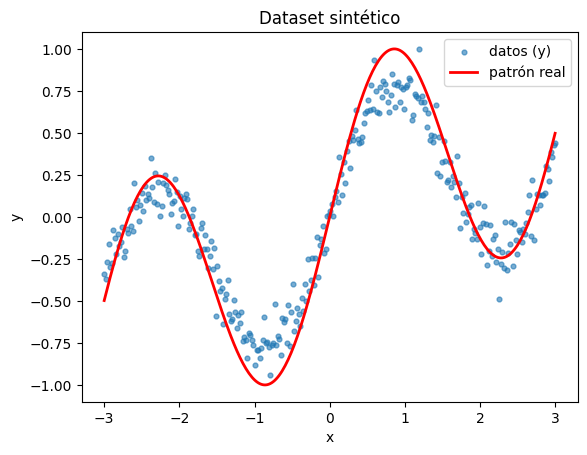

In [2]:
#Ahora bien empezamos creando los datos de entrada
np.random.seed(42)
n = 300
x = np.linspace(-3,3, n)


#Agregamos el patron no lineal 
patron = np.sin(2 * x) + 0.3 * x
ruido = np.random.normal(0, 0.15, size=n)
y = patron + ruido

#Para que pueda ser producible necesitamos que esté entre ~[-1, 1], entonces necesitamos reescalar
y = y / np.max(np.abs(y))


#grafico para entender lo que se ha hecho
plt.scatter(x, y, s=12, alpha=0.6, label="datos (y)")
plt.plot(x, patron / np.max(np.abs(patron)), 'r-', lw=2, label="patrón real")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Dataset sintético")
plt.show()

## Funciones base del modelo

Aquí haremos 3 partes claves del modelo para avanzar, y las piezas claves son:

- forward, el modelo hace su predicción
- J_mse, cuando nos referimos al cálculo del error
- grad, es el cálculo de la corrección

Con esto, el modelo predice con ŷ = tanh(wx + b). Estas funciones se usan una tras otra: se predice → se mide el error → se corrige.

In [3]:
#Prediccion, costo y gradiente con tanh

def forward(w,b):
    z = w * x + b
    return np.tanh(z)

def J_mse(w,b):
    yhat = forward(w,b)
    return np.mean((yhat - y)**2)

def grad(w,b):
    yhat = forward(w,b)
    e = yhat - y   # (ŷ - y)
    factor = (1 - yhat**2) #derivada de tanh
    dw = (2/n) * np.sum(e * factor * x)
    db = (2/n) * np.sum(e * factor)
    return dw, db

#probamos de que todo cargue bien
print("J de prueba (w=0.5, b=0):", J_mse(0.5, 0.0))

J de prueba (w=0.5, b=0): 0.36719564082237405


## Dataset sintético

El enunciado indicaba contar con una función no lineal que no fuera una `tanh` sola. Elegimos **sin(2x) + 0.3x**: primero, porque el 2 aumenta la frecuencia para que se vean varias oscilaciones en el rango seleccionado de [-3, 3]; y para agregar un poco de inclinación, tomamos la suma de 0.3x, de modo que se rompa un poco la simetría que normalmente tiene el seno.

**Rango [-3, 3]:** Elegimos un rango simétrico respecto al cero, como recomienda el enunciado. El tamaño (±3) lo elegimos para evitar la saturación de la `tanh` y el *vanishing gradient*: con valores muy grandes, `tanh(z) ≈ ±1`, el factor `(1 - ŷ²)` tiende a cero y el gradiente se anula, por lo que el modelo dejaría de aprender.

## 1a) Implementación del Gradiente Descendente

Implementamos el algoritmo de Gradiente Descendente (GD) desde cero para minimizar J(w, b), bajo la siguiente consigna:

- 100 épocas y 3 learning rates: `0.1`, `0.01`, `0.001`
- Inicialización de `w` y `b` aleatoria con `np.random.randn()`
- Graficar J(w, b) vs época, las 3 curvas superpuestas, con distinto color y leyenda

*El optimizador se implementa desde cero (numpy/matplotlib). No se permite PyTorch ni TensorFlow.*

Tenemos el punto inicial: w= 1.7641, b= 0.4002

lr=0.1:  w=1.5285, b=0.0517,  J final=0.52363
lr=0.01:  w=1.7497, b=0.3292,  J final=0.54001
lr=0.001:  w=1.7628, b=0.3925,  J final=0.54470


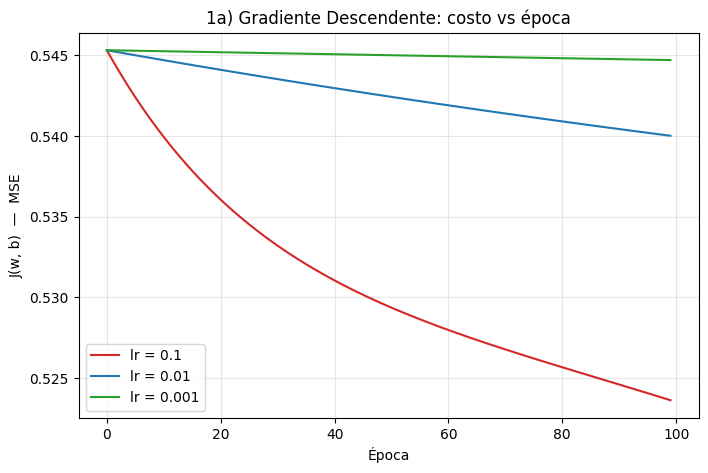

In [4]:
# Inicializamos los paramentros de forma aleatoria
np.random.seed(0)
w_init = np.random.randn()
b_init = np.random.randn()
print(f"Tenemos el punto inicial: w={w_init: .4f}, b={b_init: .4f}\n")

# Como siguiente paso, vamos con la preparacion

epocas = 100
learning_rate = [0.1, 0.01, 0.001]
historias = {}

#creamos un loop por cada learning rate, que seria un loop externo y un loop interno para las epocas

for lr in learning_rate: #este es el loop externo que se hace para la lista de learning rate
    w, b = w_init, b_init # reset desde el punto inicial
    costos = [J_mse(w,b)] #inicializamos la lista de costos

    for epoca in range (epocas-1):
        dw, db = grad(w,b) #se hace el calculo del gradiente, la pendiente
        w = w  - lr * dw 
        b = b - lr * db
        costos.append(J_mse(w,b)) #se calcula el costo y se agrega a la lista de costos
    
    historias[lr] = costos
    print(f"lr={lr}:  w={w:.4f}, b={b:.4f},  J final={costos[-1]:.5f}")


#Grafiquemos para ver como se visualiza curva

plt.figure(figsize=(8,5))
colores = {0.1: 'tab:red', 0.01: 'tab:blue', 0.001: 'tab:green'}
for lr in learning_rate:
    plt.plot(historias[lr], color=colores[lr], label=f"lr = {lr}")

plt.xlabel("Época")
plt.ylabel("J(w, b)  —  MSE")
plt.title("1a) Gradiente Descendente: costo vs época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Conclusión 1a

El learning rate con mejor rendimiento fue **0.1**, que bajó el costo más rápido en las 100 épocas. El lr = 0.001 apenas se movió, porque da pasos muy pequeños y con solo 100 épocas se queda corto.

Se observa que el learning rate y la cantidad de épocas están relacionados: un lr pequeño necesitaría muchas más épocas para converger. De hecho, ninguno de los tres llegó a converger del todo en las 100 épocas.

<br><br>

## 1b) Implementación de Adam

Implementamos el optimizador Adam desde cero para minimizar J(w, b), reutilizando el mismo dataset y funciones del 1a. La consigna:

- Mismos `w` y `b` iniciales que en GD (importante, para comparación justa)
- 100 épocas y los 3 learning rates: `0.1`, `0.01`, `0.001`
- Dos versiones: **full-batch** (todos los datos por época) y **mini-batch** (batch size ≥ 16)
- Graficar J(w, b) vs época en 2 plots separados: uno para full-batch, otro para mini-batch

*Adam se implementa desde cero (numpy/matplotlib). No se permite PyTorch ni TensorFlow.*

lr=0.1:  w=0.0861, b=0.0006,  J final=0.17659
lr=0.01:  w=0.3283, b=0.0062,  J final=0.27369
lr=0.001:  w=1.6577, b=0.3043,  J final=0.53675


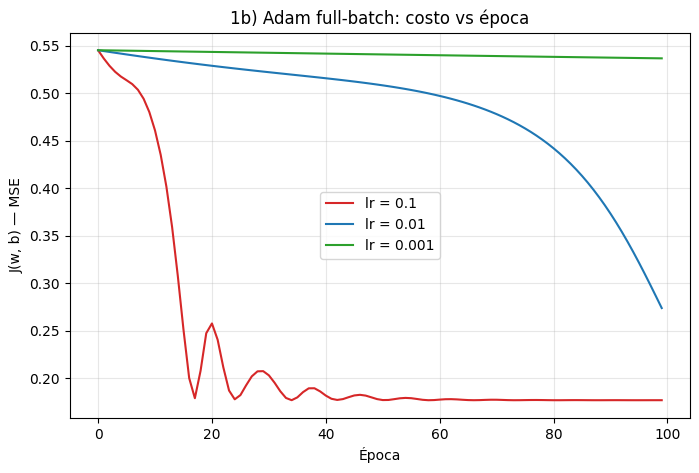

In [5]:
#Inciso 1b Adam full-batch desde 0

epocas = 100
learning_rate = [0.1, 0.01, 0.001]
beta1, beta2 = 0.9, 0.999
eps = 1e-8
historias_adam = {} #hay que guardar la curva de costo para cada learning rate

for lr in learning_rate:

    w, b = w_init, b_init # reset desde el punto inicial

    #memorias de Adam
    mw, mb = 0.0, 0.0
    vw, vb = 0.0, 0.0
    costos = [J_mse(w,b)] #inicializamos la lista de costos

    for t in range(1, epocas):
        dw, db = grad(w,b) #se hace el calculo del gradiente, la pendiente

        #actualizamos las memorias de Adam
        mw = beta1 * mw + (1 - beta1) * dw
        mb = beta1 * mb + (1 - beta1) * db
        vw = beta2 * vw + (1 - beta2) * (dw**2)
        vb = beta2 * vb + (1 - beta2) * (db**2)

        #correccion de sesgo
        mw_hat = mw / (1 - beta1**t)
        mb_hat = mb / (1 - beta1**t)
        vw_hat = vw / (1 - beta2**t)
        vb_hat = vb / (1 - beta2**t)

        #actualizamos los parametros
        w = w - lr * mw_hat / (np.sqrt(vw_hat) + eps)
        b = b - lr * mb_hat / (np.sqrt(vb_hat) + eps)
    

        costos.append(J_mse(w,b)) #se calcula el costo y se agrega a la lista de costos

    historias_adam[lr] = costos
    print(f"lr={lr}:  w={w:.4f}, b={b:.4f},  J final={costos[-1]:.5f}")


# --- Gráfica ---
plt.figure(figsize=(8,5))
colores = {0.1: 'tab:red', 0.01: 'tab:blue', 0.001: 'tab:green'}
for lr in learning_rate:
    plt.plot(historias_adam[lr], color=colores[lr], label=f"lr = {lr}")
plt.xlabel("Época")
plt.ylabel("J(w, b) — MSE")
plt.title("1b) Adam full-batch: costo vs época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

lr=0.1:  w=0.1117, b=0.0129,  J final=0.17807
lr=0.01:  w=0.0957, b=-0.0001,  J final=0.17670
lr=0.001:  w=0.1387, b=-0.0015,  J final=0.18266


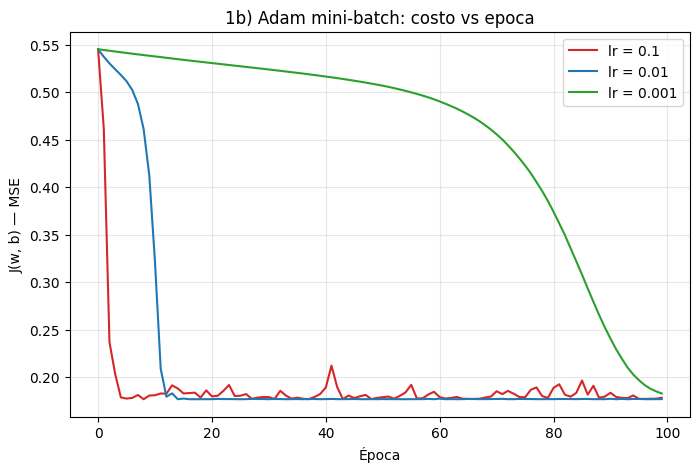

In [6]:
#Ahora vamos la segundo parte del inciso que es hacer el mini-batch, desde 0

#recibimos el lote

def grad_batch(w,b, x_b, y_b):
    yhat = np.tanh(w * x_b + b)
    e = yhat - y_b
    factor = (1 - yhat**2)
    m = len(x_b) # size del lote
    dw = (2/m) * np.sum(e * factor * x_b)
    db = (2/m) * np.sum(e * factor)
    return dw, db

epocas = 100
learning_rate = [0.1, 0.01, 0.001]
beta1, beta2 = 0.9, 0.999
eps = 1e-8
batch_size = 32 # >=16

historias_adam_mini= {}

for lr in learning_rate:
    w, b = w_init, b_init # reset desde el punto inicial
    mw, mb = 0.0, 0.0
    vw, vb = 0.0, 0.0
    t = 0 
    costos = [J_mse(w,b)] #inicializamos la lista de costos

    for epoca in range(epocas -1):
        idx = np.random.permutation(n)
        x_shuf, y_shuf = x[idx], y[idx]

        
        for inicio in range(0, n, batch_size):
            x_b = x_shuf[inicio:inicio + batch_size]
            y_b = y_shuf[inicio:inicio + batch_size]

            t += 1
            dw, db = grad_batch(w, b, x_b, y_b)   # gradiente del LOTE

            mw = beta1*mw + (1-beta1)*dw
            mb = beta1*mb + (1-beta1)*db
            vw = beta2*vw + (1-beta2)*(dw**2)
            vb = beta2*vb + (1-beta2)*(db**2)

            mw_hat = mw / (1-beta1**t)
            mb_hat = mb / (1-beta1**t)
            vw_hat = vw / (1-beta2**t)
            vb_hat = vb / (1-beta2**t)

            w = w - lr * mw_hat / (np.sqrt(vw_hat) + eps)
            b = b - lr * mb_hat / (np.sqrt(vb_hat) + eps)

        
        costos.append(J_mse(w, b))

    historias_adam_mini[lr] = costos
    print(f"lr={lr}:  w={w:.4f}, b={b:.4f},  J final={costos[-1]:.5f}")

# --- Gráfica ---
plt.figure(figsize=(8,5))
colores = {0.1: 'tab:red', 0.01: 'tab:blue', 0.001: 'tab:green'}
for lr in learning_rate:
    plt.plot(historias_adam_mini[lr], color=colores[lr], label=f"lr = {lr}")
plt.xlabel("Época")
plt.ylabel("J(w, b) — MSE")
plt.title("1b) Adam mini-batch: costo vs epoca")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 1c) Comparativa de optimizadores

Comparamos los tres optimizadores implementados (GD, Adam full-batch y Adam mini-batch) reutilizando los resultados de los incisos anteriores. La consigna:

- Comparar GD vs Adam-full vs Adam-mini para cada learning rate → 3 subplots (uno por lr), con los optimizadores diferenciados por color
- Graficar el dataset original vs la función aprendida por cada modelo → 9 subplots (3 optimizadores × 3 learning rates)
- Redactar conclusiones analíticas sobre resultado final, velocidad de convergencia y demás aspectos relevantes

### Conclusiones 1c

Llegando a la parte final de este ejercicio, en esta comparativa hay varias perspectivas que vale la pena analizar con detenimiento. Vamos en orden:

**Gradiente Descendente:** Al ejecutar las gráficas, notamos que el learning rate más grande (0.1) tiene mejor rendimiento que los pasos más pequeños, y su desarrollo en la gráfica es claramente distinto. Sin embargo, incluso el mejor caso se queda corto: en 100 épocas avanza muy poco y no llega a converger del todo.

**Adam full-batch:** Conviene separar el análisis de full-batch y mini-batch, porque aunque están relacionados, su rendimiento es bastante diferente. Lo que sobresale de Adam frente a GD es la **normalización**: es el factor clave que ajusta el paso cuando los gradientes son grandes. En full-batch vemos que el lr=0.1 tiene mucho rebote (oscila), mientras que el 0.01 logra el mejor rendimiento por ser un paso más equilibrado. En cambio, el 0.001, al ser un paso demasiado pequeño, casi no avanza a pesar de arrancar bien.

**Adam mini-batch:** Sin conocer cómo funciona, esperaríamos el mismo comportamiento que full-batch, pero la forma es distinta: ganamos velocidad a cambio de perder suavidad. ¿Qué quiere decir esto? Que al dar más pasos (uno por cada lote), el modelo converge más rápido, pero cada paso tiene más ruido, por lo que la curva rebota y no es tan limpia. Un detalle interesante: acá hasta el lr=0.001 logra converger, porque la mayor cantidad de pasos le da tiempo de llegar, cosa que en full-batch no pasaba.

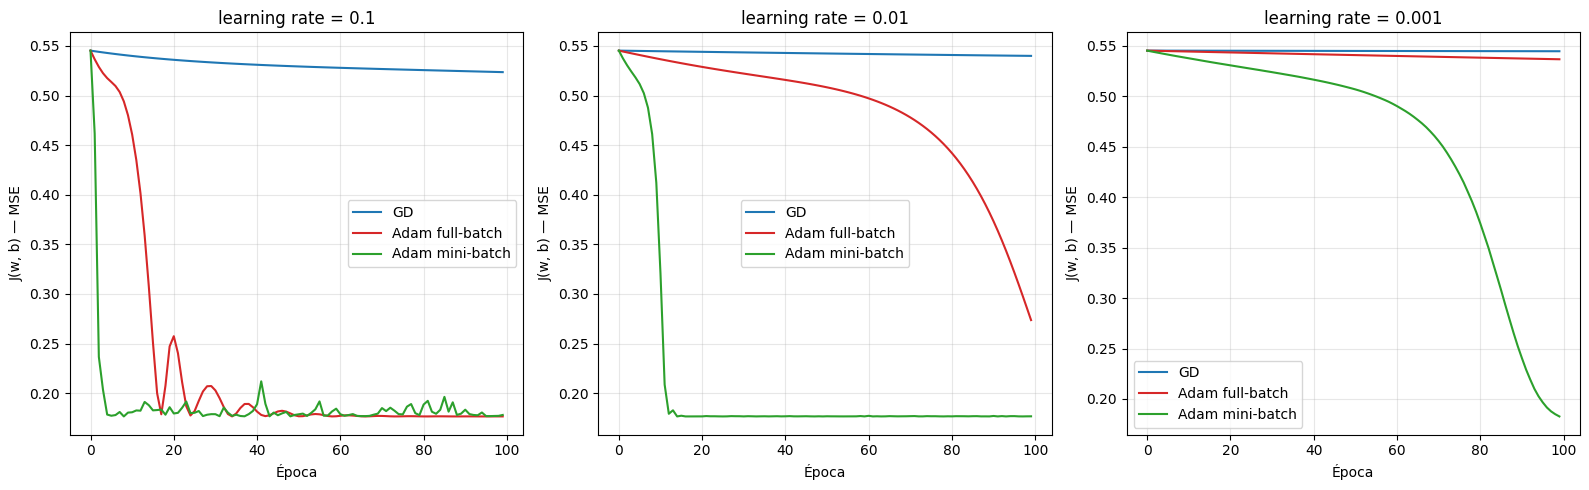

In [7]:
#1c) Comparativa: GD vs Adam-full vs Adam-mini, por learning rate

fig, axes = plt.subplots(1, 3, figsize=(16, 5))   # 3 subplots lado a lado

for i, lr in enumerate(learning_rate):
    ax = axes[i]
    ax.plot(historias[lr],            color='tab:blue',   label='GD')
    ax.plot(historias_adam[lr],  color='tab:red',    label='Adam full-batch')
    ax.plot(historias_adam_mini[lr],  color='tab:green',  label='Adam mini-batch')
    ax.set_title(f'learning rate = {lr}')
    ax.set_xlabel('Época')
    ax.set_ylabel('J(w, b) — MSE')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Analizando los tres paneles (uno por learning rate), lo que se evalúa es el comportamiento de cada optimizador según el paso que damos.

Para el **Gradiente Descendente**, el mejor caso fue lr=0.1, pero aun así avanza muy poco: con ningún learning rate llega a converger en 100 épocas. De ahí surge la duda: ¿cómo mejoramos el rendimiento?

Pasamos a **Adam**, que gracias a la normalización del paso llega mucho más lejos con la misma cantidad de épocas. El costo es un poco más de complejidad (mantener las medias móviles y la corrección de sesgo), pero el resultado lo justifica: con lr=0.1 y 0.01 llega al fondo, mientras que GD no.

Finalmente, con **Adam mini-batch** ganamos velocidad al dar más pasos por época. Lo más notable es que converge en todos los casos, incluso con lr=0.001 (algo que ni GD ni Adam full-batch lograron), aunque en ese caso tarde más. El mejor comportamiento de todo el experimento es el de mini-batch con lr=0.01: baja rápido y se estabiliza limpio, siendo el combo más eficiente.

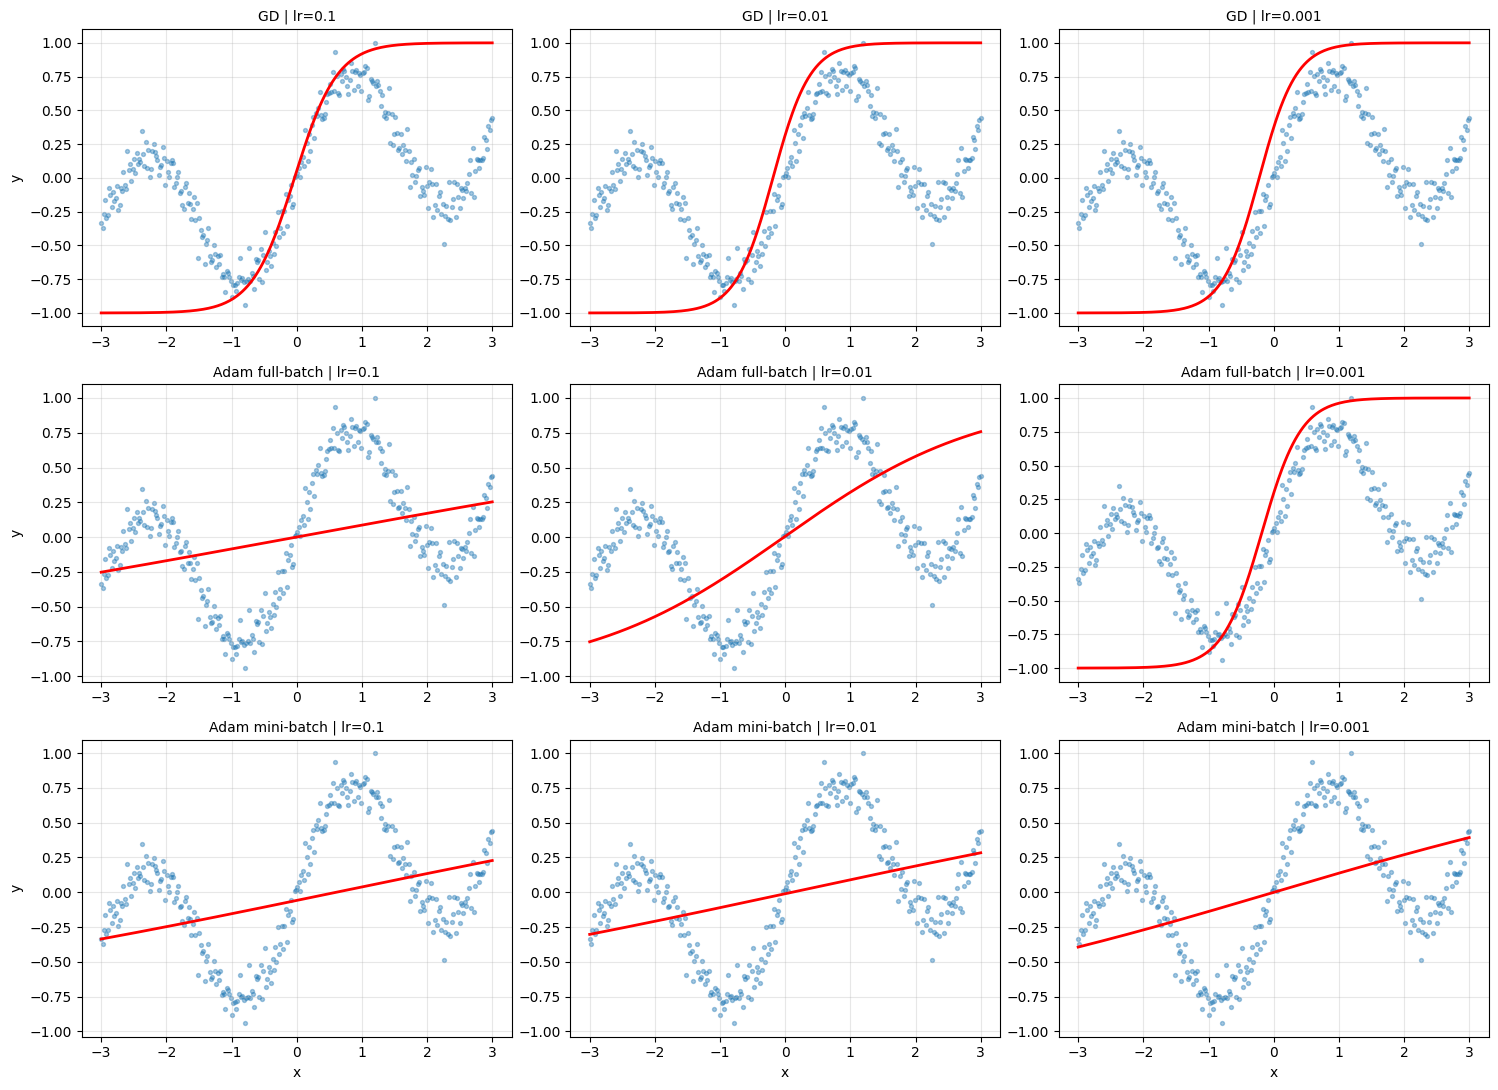

In [8]:
# 1c) Función aprendida por cada modelo (9 subplots) 

# aqui debemos de entrenar cada optimizador guardando los w,b finales (no la curva)
def entrenar_gd(lr):
    w, b = w_init, b_init
    for _ in range(epocas - 1):
        dw, db = grad(w, b)
        w -= lr * dw; b -= lr * db
    return w, b

def entrenar_adam_full(lr):
    w, b = w_init, b_init
    mw = mb = vw = vb = 0.0
    for t in range(1, epocas):
        dw, db = grad(w, b)
        mw = beta1*mw + (1-beta1)*dw;  mb = beta1*mb + (1-beta1)*db
        vw = beta2*vw + (1-beta2)*dw**2; vb = beta2*vb + (1-beta2)*db**2
        mw_h = mw/(1-beta1**t); mb_h = mb/(1-beta1**t)
        vw_h = vw/(1-beta2**t); vb_h = vb/(1-beta2**t)
        w -= lr*mw_h/(np.sqrt(vw_h)+eps); b -= lr*mb_h/(np.sqrt(vb_h)+eps)
    return w, b

def entrenar_adam_mini(lr):
    w, b = w_init, b_init
    mw = mb = vw = vb = 0.0; t = 0
    for _ in range(epocas - 1):
        idx = np.random.permutation(n)
        x_s, y_s = x[idx], y[idx]
        for ini in range(0, n, batch_size):
            xb, yb = x_s[ini:ini+batch_size], y_s[ini:ini+batch_size]
            t += 1
            dw, db = grad_batch(w, b, xb, yb)
            mw = beta1*mw + (1-beta1)*dw;  mb = beta1*mb + (1-beta1)*db
            vw = beta2*vw + (1-beta2)*dw**2; vb = beta2*vb + (1-beta2)*db**2
            mw_h = mw/(1-beta1**t); mb_h = mb/(1-beta1**t)
            vw_h = vw/(1-beta2**t); vb_h = vb/(1-beta2**t)
            w -= lr*mw_h/(np.sqrt(vw_h)+eps); b -= lr*mb_h/(np.sqrt(vb_h)+eps)
    return w, b

optimizadores = {
    "GD": entrenar_gd,
    "Adam full-batch": entrenar_adam_full,
    "Adam mini-batch": entrenar_adam_mini,
}

#Grilla de 9 subplots: filas = optimizadores, columnas = learning rate
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
x_orden = np.sort(x)   # x ordenado, para dibujar la curva aprendida suave

for fila, (nombre, entrenar) in enumerate(optimizadores.items()):
    for col, lr in enumerate(learning_rate):
        w_f, b_f = entrenar(lr)                      # entreno y saco w,b finales
        y_pred = np.tanh(w_f * x_orden + b_f)        # curva que aprendió

        ax = axes[fila, col]
        ax.scatter(x, y, s=8, alpha=0.4, label="datos")
        ax.plot(x_orden, y_pred, 'r-', lw=2, label="modelo")
        ax.set_title(f"{nombre} | lr={lr}", fontsize=10)
        ax.grid(alpha=0.3)
        if fila == 2: ax.set_xlabel("x")
        if col == 0:  ax.set_ylabel("y")

plt.tight_layout()
plt.show()

Este gráfico refleja algo que vimos en clase: en algún momento, una sola neurona no es suficiente para aprender el patrón que buscamos.

¿Por qué no alcanza una sola neurona? Porque la función `tanh` solo puede dibujar **una única curva en forma de S**, mientras que nuestro patrón (basado en un seno) tiene **varias ondas**. Una sola S no puede seguir varias subidas y bajadas: lo máximo que logra es ajustar la tendencia central (como se ve en GD) o promediar los datos con una recta casi plana (como en Adam mini-batch con learning rates chicos).

Lo importante es que esto **no se resuelve con más entrenamiento**: por más épocas que le demos, una sola neurona no tiene la capacidad de representar un patrón tan complejo. Es una limitación del modelo, no del optimizador. Para capturarlo harían falta más neuronas o capas ocultas, que combinadas sí pueden formar curvas más complejas.

## 1d) Visualización 3D de las trayectorias

Graficamos en 3D la trayectoria de aprendizaje de los tres optimizadores (GD, Adam full-batch y Adam mini-batch) sobre la superficie de costo J(w, b). Elegimos el learning rate 0.01 porque es donde se ve bien marcada la diferencia entre los tres optimizadores. Las tres trayectorias parten del mismo punto inicial.

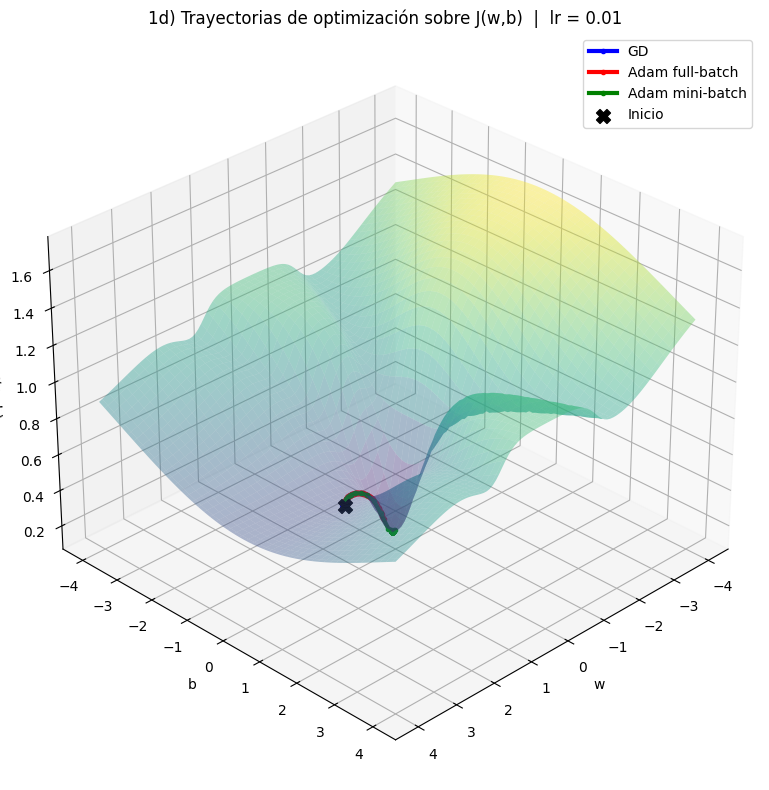

In [9]:
#  1d) Trayectorias 3D de los 3 optimizadores (lr = 0.01)
from mpl_toolkits.mplot3d import Axes3D

lr_3d = 0.01   # el learning rate elegido

#entrenamos guardando trayectoria (w, b en cada paso)
def tray_gd(lr):
    w, b = w_init, b_init
    ws, bs = [w], [b]
    for _ in range(epocas - 1):
        dw, db = grad(w, b)
        w -= lr*dw; b -= lr*db
        ws.append(w); bs.append(b)
    return np.array(ws), np.array(bs)

def tray_adam_full(lr):
    w, b = w_init, b_init
    mw=mb=vw=vb=0.0
    ws, bs = [w], [b]
    for t in range(1, epocas):
        dw, db = grad(w, b)
        mw=beta1*mw+(1-beta1)*dw; mb=beta1*mb+(1-beta1)*db
        vw=beta2*vw+(1-beta2)*dw**2; vb=beta2*vb+(1-beta2)*db**2
        mwh=mw/(1-beta1**t); mbh=mb/(1-beta1**t)
        vwh=vw/(1-beta2**t); vbh=vb/(1-beta2**t)
        w-=lr*mwh/(np.sqrt(vwh)+eps); b-=lr*mbh/(np.sqrt(vbh)+eps)
        ws.append(w); bs.append(b)
    return np.array(ws), np.array(bs)

def tray_adam_mini(lr):
    w, b = w_init, b_init
    mw=mb=vw=vb=0.0; t=0
    ws, bs = [w], [b]
    for _ in range(epocas - 1):
        idx = np.random.permutation(n)
        x_s, y_s = x[idx], y[idx]
        for ini in range(0, n, batch_size):
            xb, yb = x_s[ini:ini+batch_size], y_s[ini:ini+batch_size]
            t += 1
            dw, db = grad_batch(w, b, xb, yb)
            mw=beta1*mw+(1-beta1)*dw; mb=beta1*mb+(1-beta1)*db
            vw=beta2*vw+(1-beta2)*dw**2; vb=beta2*vb+(1-beta2)*db**2
            mwh=mw/(1-beta1**t); mbh=mb/(1-beta1**t)
            vwh=vw/(1-beta2**t); vbh=vb/(1-beta2**t)
            w-=lr*mwh/(np.sqrt(vwh)+eps); b-=lr*mbh/(np.sqrt(vbh)+eps)
        ws.append(w); bs.append(b)   # guardamos 1 punto por época
    return np.array(ws), np.array(bs)

# Obtenemos las 3 trayectorias
gd_w, gd_b       = tray_gd(lr_3d)
af_w, af_b       = tray_adam_full(lr_3d)
am_w, am_b       = tray_adam_mini(lr_3d)

#Superficie de costo J(w,b) sobre una malla
w_range = np.linspace(-4, 4, 100)
b_range = np.linspace(-4, 4, 100)
WW, BB = np.meshgrid(w_range, b_range)
JJ = np.zeros_like(WW)
for i in range(WW.shape[0]):
    for j in range(WW.shape[1]):
        JJ[i, j] = J_mse(WW[i, j], BB[i, j])

#Gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# la superficie, semitransparente
ax.plot_surface(WW, BB, JJ, alpha=0.4, cmap='viridis')

# las 3 trayectorias (calculamos J a lo largo de cada una)
def J_camino(ws, bs):
    return np.array([J_mse(w, b) for w, b in zip(ws, bs)])

ax.plot(gd_w, gd_b, J_camino(gd_w, gd_b), color='blue',  lw=3, marker='o', markersize=3, label='GD')
ax.plot(af_w, af_b, J_camino(af_w, af_b), color='red',   lw=3, marker='o', markersize=3, label='Adam full-batch')
ax.plot(am_w, am_b, J_camino(am_w, am_b), color='green', lw=3, marker='o', markersize=3, label='Adam mini-batch')

# punto de partida común
ax.scatter([w_init], [b_init], [J_mse(w_init, b_init)], color='black', s=100, marker='X', label='Inicio')

ax.set_xlabel('w'); ax.set_ylabel('b'); ax.set_zlabel('J(w, b)')
ax.set_title(f'1d) Trayectorias de optimización sobre J(w,b)  |  lr = {lr_3d}')
ax.legend()
ax.view_init(elev=30, azim=45)   # ángulo de cámara
plt.tight_layout()
plt.show()

### Conclusión 1d

En el espacio de parámetros (w, b), las tres trayectorias parten del mismo punto inicial pero se comportan de forma distinta. La trayectoria de **GD es la más corta**, con lr=0.01 apenas se desplaza del punto de partida y no llega al fondo del pozo, quedándose en una zona de costo alto. En cambio, **las trayectorias de Adam (full-batch y mini-batch) sí descienden hasta el fondo** de la superficie, alcanzando la zona de mínimo costo. Esto confirma lo visto en los incisos anteriores: con un learning rate pequeño, GD es demasiado lento para converger, mientras que Adam, gracias a la normalización del paso, logra avanzar mucho más en la misma cantidad de épocas.

<br></br>

# Pregunta 2 — Predicción del gasto promedio por cliente

En esta sección desarrollamos un modelo de deep learning (MLP en PyTorch) para predecir el **gasto promedio de cada cliente** a partir de sus **datos demográficos** (edad, género, estado civil, ciudad, antigüedad). Como buscamos estimar un valor numérico, se trata de un problema de **regresión**.

El desarrollo se divide en tres etapas: análisis y preparación del dataset (EDA), diseño y entrenamiento del MLP, y evaluación de resultados.

In [13]:
#Empezaamos con el EDA, vamos con las librerias
import pandas as pd
df = pd.read_csv('dataset_compras.csv')
print("Forma del dataset:", df.shape)
print(df.head())
#vamos a quitar columnas que no nos aportan al gasto promedio del cliente

columnas_producto = ['Product_ID', 'Product_Category','Product_Subcategory_1', 'Product_Subcategory_2']

#ahora si, hacemos drop en el dataset de las columnas

df = df.drop(columns=columnas_producto)

#ahora, necesitaremos hacer el agrupamiento, por cliente

df_clientes = df.groupby('User_ID').agg({

    'Age': 'first',
    'Gender': 'first',
    'Marital_Status': 'first',
    'City_Category': 'first',
    'Stay_In_Current_City_Years': 'first',
    'Purchase': 'mean'
    
}).reset_index()

#Bueno, ahora si vamos a lo que seria el gasto promedio

df_clientes = df_clientes.rename(columns={'Purchase': 'Gasto_Promedio'})

print("Forma original (transacciones):", df.shape)
print("Forma agrupada (clientes):", df_clientes.shape)
print()
print(df_clientes.head())


Forma del dataset: (182721, 11)
   User_ID Product_ID    Age Gender  Marital_Status City_Category  \
0  1044096  P00017122  46-50      F               1             B   
1  1071818  P00074517  36-45      M               0             A   
2  1022986  P00013694  36-45      M               1             A   
3  1094684  P00049122  36-45      M               1             A   
4  1004157  P00006469  46-50      M               1             A   

  Stay_In_Current_City_Years  Product_Category  Product_Subcategory_1  \
0                          1                10                   45.0   
1                          3                11                   27.0   
2                         5+                 4                   28.0   
3                          1                16                    9.0   
4                         5+                 3                    NaN   

   Product_Subcategory_2  Purchase  
0                    NaN      1810  
1                    NaN     12351  
2  